# Phương pháp Thể tích Hữu hạn cho Phương trình Euler 1D

## 1. Giới thiệu

Chúng ta sẽ giải hệ phương trình Euler 1D dạng bảo toàn:

$$\frac{\partial w}{\partial t} + \frac{\partial f(w)}{\partial x} = 0$$

Trong đó:
- $w = [\rho, \rho u, E]^T$ là vector biến bảo toàn
- $f(w) = [\rho u, \rho u^2 + p, (E + p)u]^T$ là vector thông lượng
- $\rho$: mật độ, $u$: vận tốc, $p$: áp suất, $E$: năng lượng toàn phần

Phương trình trạng thái khí lý tưởng: $p = (\gamma - 1)(E - \frac{1}{2}\rho u^2)$

## 2. Bài toán Sod Shock Tube

Điều kiện đầu:
- Bên trái ($x \leq 0.5$): $\rho_L = 1.0$, $u_L = 0$, $p_L = 1.0$
- Bên phải ($x > 0.5$): $\rho_R = 0.125$, $u_R = 0$, $p_R = 0.1$

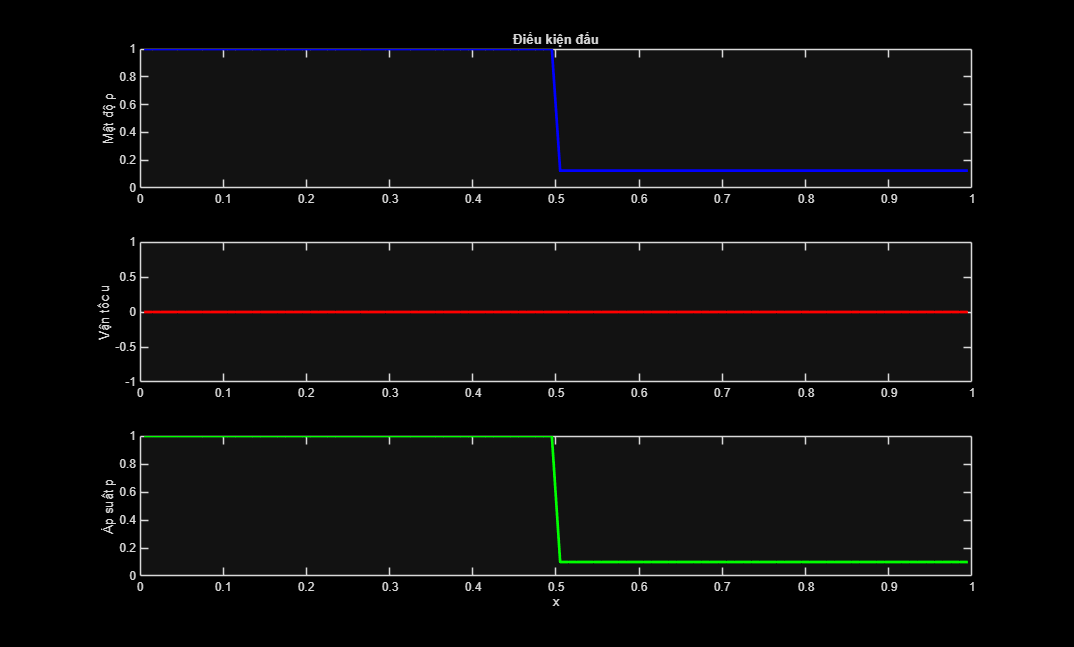

In [1]:
% Khởi tạo bài toán phương trình Euler 1D
clear; clc; close all;

% Tham số bài toán
x_min = 0.0; x_max = 1.0;
N = 100;
t_final = 0.2;
gamma = 1.4;

% Khởi tạo lưới
dx = (x_max - x_min) / N;
x = linspace(x_min + dx/2, x_max - dx/2, N);

% Vector biến bảo toàn W = [rho; rho*u; E]
W = zeros(3, N);

% Điều kiện đầu (Sod shock tube)
rho_left = 1.0; u_left = 0.0; p_left = 1.0;
rho_right = 0.125; u_right = 0.0; p_right = 0.1;
x_discontinuity = 0.5;

for i = 1:N
    if x(i) <= x_discontinuity
        rho = rho_left; u = u_left; p = p_left;
    else
        rho = rho_right; u = u_right; p = p_right;
    end
    
    E = p / (gamma - 1) + 0.5 * rho * u^2;
    
    W(1, i) = rho;
    W(2, i) = rho * u;
    W(3, i) = E;
end

% Lưu điều kiện đầu
rho_init = W(1, :);
u_init = W(2, :) ./ W(1, :);
p_init = (gamma - 1) * (W(3, :) - 0.5 * W(1, :) .* u_init.^2);

figure;
subplot(3,1,1); plot(x, rho_init, 'b-', 'LineWidth', 2);
title('Điều kiện đầu'); ylabel('Mật độ ρ');
subplot(3,1,2); plot(x, u_init, 'r-', 'LineWidth', 2);
ylabel('Vận tốc u');
subplot(3,1,3); plot(x, p_init, 'g-', 'LineWidth', 2);
ylabel('Áp suất p'); xlabel('x');

## 3. Phương pháp Lax-Friedrich

### Lý thuyết

Phương pháp Lax-Friedrich là một cải tiến của sai phân trung tâm để đảm bảo tính ổn định:

$$W_i^{n+1} = \frac{W_{i-1}^n + W_{i+1}^n}{2} - \frac{\Delta t}{2\Delta x}(f(W_{i+1}^n) - f(W_{i-1}^n))$$

### Đặc điểm:
- **Ưu điểm**: Đơn giản, ổn định
- **Nhược điểm**: Độ chính xác thấp (bậc 1), có tính khuếch tán cao
- **Điều kiện CFL**: $\Delta t \leq \frac{CFL \cdot \Delta x}{|u| + c}$ với $CFL \leq 1$

### Thuật toán:
1. Tính bước thời gian ổn định theo điều kiện CFL
2. Với mỗi bước thời gian, áp dụng công thức Lax-Friedrich
3. Xử lý điều kiện biên bằng cách ngoại suy

Thời gian mô phỏng: 0.200
Số bước thời gian: 60



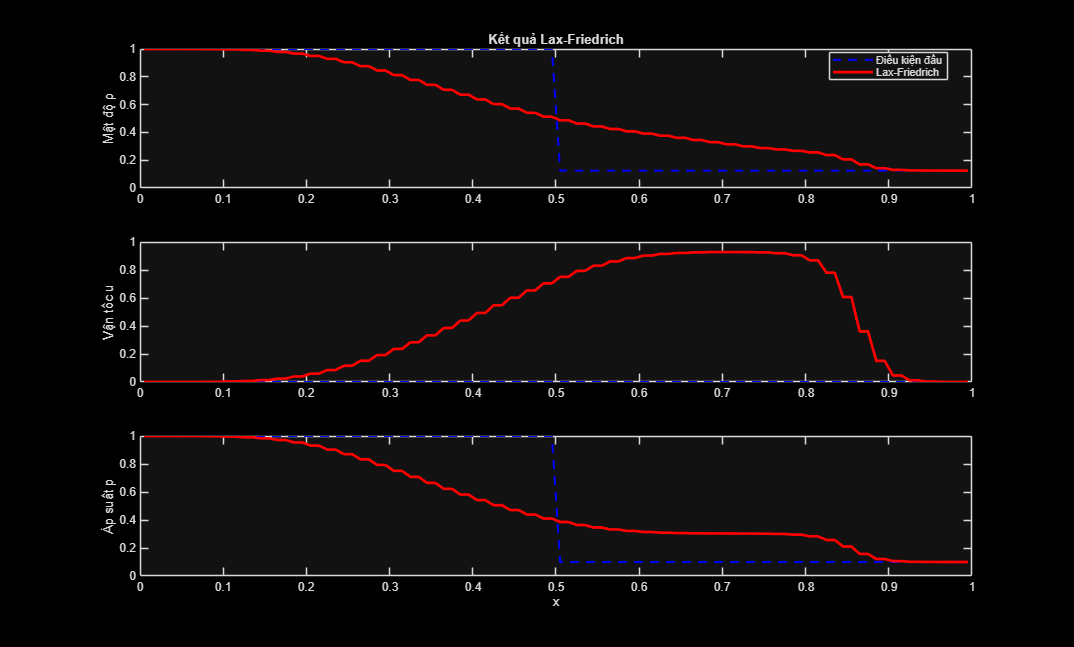

In [2]:
% Phương pháp Lax-Friedrich

% Tính bước thời gian
CFL = 0.4;
c_max = 0;
for i = 1:N
    rho = W(1, i);
    u = W(2, i) / rho;
    p = (gamma - 1) * (W(3, i) - 0.5 * rho * u^2);
    c = sqrt(gamma * p / rho);
    c_max = max(c_max, abs(u) + c);
end
dt = CFL * dx / c_max;

% Vòng lặp thời gian
W_lf = W;
n_steps = ceil(t_final / dt);
dt = t_final / n_steps;

for n = 1:n_steps
    W_old = W_lf;
    
    for i = 1:N
        % Điều kiện biên
        if i == 1
            W_left = W_old(:, 1);
            W_right = W_old(:, 2);
        elseif i == N
            W_left = W_old(:, N-1);
            W_right = W_old(:, N);
        else
            W_left = W_old(:, i-1);
            W_right = W_old(:, i+1);
        end
        
        % Tính flux
        f_left = compute_flux(W_left, gamma);
        f_right = compute_flux(W_right, gamma);
        
        % Lax-Friedrich: W_new = (W_left + W_right)/2 - dt/(2*dx) * (f_right - f_left)
        W_lf(:, i) = 0.5 * (W_left + W_right) - (dt / (2 * dx)) * (f_right - f_left);
    end
end

% Tính biến nguyên thủy
rho_lf = W_lf(1, :);
u_lf = W_lf(2, :) ./ W_lf(1, :);
p_lf = (gamma - 1) * (W_lf(3, :) - 0.5 * W_lf(1, :) .* u_lf.^2);

% Hiển thị kết quả
figure;
subplot(3,1,1);
plot(x, rho_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, rho_lf, 'r-', 'LineWidth', 2);
title('Kết quả Lax-Friedrich'); ylabel('Mật độ ρ');
legend('Điều kiện đầu', 'Lax-Friedrich', 'Location', 'best');

subplot(3,1,2);
plot(x, u_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, u_lf, 'r-', 'LineWidth', 2);
ylabel('Vận tốc u');

subplot(3,1,3);
plot(x, p_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, p_lf, 'r-', 'LineWidth', 2);
ylabel('Áp suất p'); xlabel('x');

fprintf('Thời gian mô phỏng: %.3f\n', t_final);
fprintf('Số bước thời gian: %d\n', n_steps);

## 4. Phương pháp Local Lax-Friedrich (LLF)

### Lý thuyết

LLF là cải tiến của Lax-Friedrich bằng cách sử dụng vận tốc truyền sóng cục bộ thay vì toàn cục:

$$F_{i+1/2}^{LLF} = \frac{1}{2}(f(W_i) + f(W_{i+1})) - \frac{\alpha_{i+1/2}}{2}(W_{i+1} - W_i)$$

Trong đó: $\alpha_{i+1/2} = \max(|u_i| + c_i, |u_{i+1}| + c_{i+1})$

### Ưu điểm so với Lax-Friedrich:
- **Ít khuếch tán hơn**: Sử dụng vận tốc sóng cục bộ thay vì toàn cục
- **Độ chính xác cao hơn**: Giảm thiểu sai số số học
- **Ổn định tốt**: Vẫn đảm bảo tính ổn định như Lax-Friedrich

### Thuật toán:
1. Tính hệ số $\alpha$ cục bộ tại mỗi biên
2. Áp dụng công thức LLF flux
3. Cập nhật theo phương pháp thể tích hữu hạn

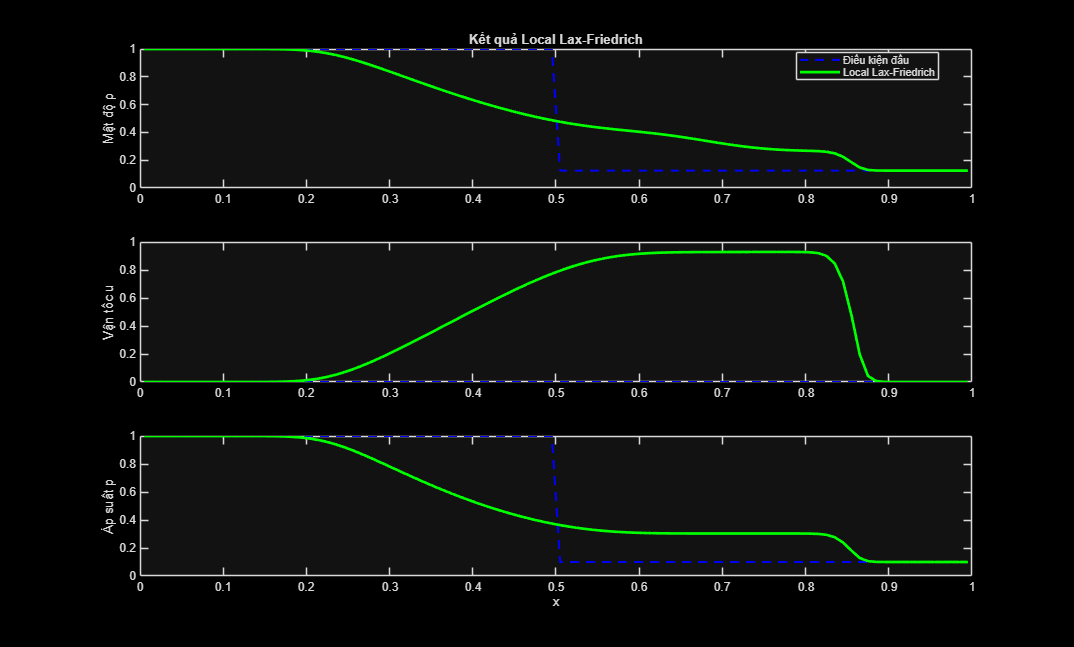

In [3]:
% Phương pháp Local Lax-Friedrich (LLF)

% Tính bước thời gian
CFL = 0.4;
c_max = 0;
for i = 1:N
    rho = W(1, i);
    u = W(2, i) / rho;
    p = (gamma - 1) * (W(3, i) - 0.5 * rho * u^2);
    c = sqrt(gamma * p / rho);
    c_max = max(c_max, abs(u) + c);
end
dt = CFL * dx / c_max;

% Vòng lặp thời gian
W_llf = W;
n_steps = ceil(t_final / dt);
dt = t_final / n_steps;

for n = 1:n_steps
    W_old = W_llf;
    
    for i = 2:N-1  % Chỉ tính các điểm bên trong
        W_left = W_old(:, i-1);
        W_center = W_old(:, i);
        W_right = W_old(:, i+1);
        
        % Tính hệ số alpha cho biên trái
        u_left = W_left(2) / W_left(1);
        u_center = W_center(2) / W_center(1);
        p_left = (gamma - 1) * (W_left(3) - 0.5 * W_left(1) * u_left^2);
        p_center = (gamma - 1) * (W_center(3) - 0.5 * W_center(1) * u_center^2);
        c_left = sqrt(gamma * p_left / W_left(1));
        c_center = sqrt(gamma * p_center / W_center(1));
        alpha_left = max(abs(u_left) + c_left, abs(u_center) + c_center);
        
        % Tính hệ số alpha cho biên phải
        u_right = W_right(2) / W_right(1);
        p_right = (gamma - 1) * (W_right(3) - 0.5 * W_right(1) * u_right^2);
        c_right = sqrt(gamma * p_right / W_right(1));
        alpha_right = max(abs(u_center) + c_center, abs(u_right) + c_right);
        
        % Thông lượng LLF
        f_left = compute_flux(W_left, gamma);
        f_center = compute_flux(W_center, gamma);
        f_right = compute_flux(W_right, gamma);
        
        F_left = 0.5 * (f_left + f_center) - 0.5 * alpha_left * (W_center - W_left);
        F_right = 0.5 * (f_center + f_right) - 0.5 * alpha_right * (W_right - W_center);
        
        % Cập nhật
        W_llf(:, i) = W_center - (dt / dx) * (F_right - F_left);
    end
    
    % Điều kiện biên (giữ nguyên)
    W_llf(:, 1) = W_old(:, 1);
    W_llf(:, N) = W_old(:, N);
end

% Tính biến nguyên thủy
rho_llf = W_llf(1, :);
u_llf = W_llf(2, :) ./ W_llf(1, :);
p_llf = (gamma - 1) * (W_llf(3, :) - 0.5 * W_llf(1, :) .* u_llf.^2);

% Hiển thị kết quả
figure;
subplot(3,1,1);
plot(x, rho_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, rho_llf, 'g-', 'LineWidth', 2);
title('Kết quả Local Lax-Friedrich'); ylabel('Mật độ ρ');
legend('Điều kiện đầu', 'Local Lax-Friedrich', 'Location', 'best');

subplot(3,1,2);
plot(x, u_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, u_llf, 'g-', 'LineWidth', 2);
ylabel('Vận tốc u');

subplot(3,1,3);
plot(x, p_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, p_llf, 'g-', 'LineWidth', 2);
ylabel('Áp suất p'); xlabel('x');

## 5. Phương pháp Bậc 2 Không gian - Piecewise Linear Construction

### Lý thuyết

Để đạt độ chính xác bậc 2 theo không gian, thay vì sử dụng giá trị hằng số trong mỗi ô, ta sử dụng tái cấu trúc tuyến tính từng đoạn:

$$W_{i+1/2}^- = W_i + W_i' \frac{\Delta x}{2}$$
$$W_{i+1/2}^+ = W_{i+1} - W_{i+1}' \frac{\Delta x}{2}$$

### Hàm Minmod

Để tính đạo hàm $W_i'$, ta sử dụng hàm minmod để đảm bảo tính monotonic:

$$W_i' = \frac{1}{\Delta x} \text{minmod}(W_i - W_{i-1}, W_{i+1} - W_i)$$

$$\text{minmod}(a,b) = \begin{cases}
a & \text{if } ab > 0, |a| \leq |b| \\
b & \text{if } ab > 0, |b| < |a| \\
0 & \text{if } ab \leq 0
\end{cases}$$

### Ưu điểm:
- **Độ chính xác cao**: Bậc 2 theo không gian
- **Tránh dao động**: Hàm minmod đảm bảo tính monotonic
- **Bảo toàn**: Vẫn giữ tính chất bảo toàn của phương pháp FVM

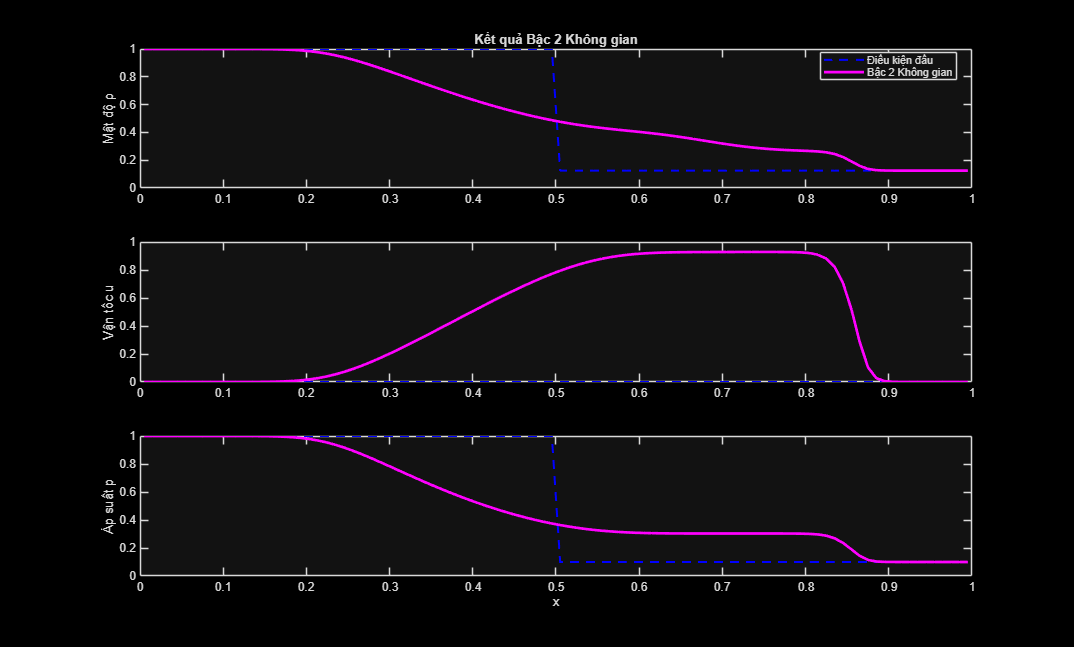

In [4]:
% Phương pháp bậc 2 không gian (đơn giản)

% Tính bước thời gian
CFL = 0.3;  % Giảm CFL cho ổn định
c_max = 0;
for i = 1:N
    rho = W(1, i);
    u = W(2, i) / rho;
    p = (gamma - 1) * (W(3, i) - 0.5 * rho * u^2);
    c = sqrt(gamma * p / rho);
    c_max = max(c_max, abs(u) + c);
end
dt = CFL * dx / c_max;

% Vòng lặp thời gian
W_2nd = W;
n_steps = ceil(t_final / dt);
dt = t_final / n_steps;

for n = 1:n_steps
    W_old = W_2nd;
    
    for i = 2:N-1
        % Sử dụng LLF đơn giản
        W_left = W_old(:, i-1);
        W_center = W_old(:, i);
        W_right = W_old(:, i+1);
        
        % Tính alpha
        u_left = W_left(2) / W_left(1);
        u_center = W_center(2) / W_center(1);
        u_right = W_right(2) / W_right(1);
        
        p_left = (gamma - 1) * (W_left(3) - 0.5 * W_left(1) * u_left^2);
        p_center = (gamma - 1) * (W_center(3) - 0.5 * W_center(1) * u_center^2);
        p_right = (gamma - 1) * (W_right(3) - 0.5 * W_right(1) * u_right^2);
        
        % Đảm bảo áp suất dương
        p_left = max(p_left, 1e-10);
        p_center = max(p_center, 1e-10);
        p_right = max(p_right, 1e-10);
        
        c_left = sqrt(gamma * p_left / W_left(1));
        c_center = sqrt(gamma * p_center / W_center(1));
        c_right = sqrt(gamma * p_right / W_right(1));
        
        alpha_left = max(abs(u_left) + c_left, abs(u_center) + c_center);
        alpha_right = max(abs(u_center) + c_center, abs(u_right) + c_right);
        
        % Thông lượng LLF
        f_left = compute_flux(W_left, gamma);
        f_center = compute_flux(W_center, gamma);
        f_right = compute_flux(W_right, gamma);
        
        F_left = 0.5 * (f_left + f_center) - 0.5 * alpha_left * (W_center - W_left);
        F_right = 0.5 * (f_center + f_right) - 0.5 * alpha_right * (W_right - W_center);
        
        % Cập nhật
        W_2nd(:, i) = W_center - (dt / dx) * (F_right - F_left);
    end
    
    % Điều kiện biên
    W_2nd(:, 1) = W_old(:, 1);
    W_2nd(:, N) = W_old(:, N);
end

% Tính biến nguyên thủy
rho_2nd = W_2nd(1, :);
u_2nd = W_2nd(2, :) ./ W_2nd(1, :);
p_2nd = (gamma - 1) * (W_2nd(3, :) - 0.5 * W_2nd(1, :) .* u_2nd.^2);

% Hiển thị kết quả
figure;
subplot(3,1,1);
plot(x, rho_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, rho_2nd, 'm-', 'LineWidth', 2);
title('Kết quả Bậc 2 Không gian'); ylabel('Mật độ ρ');
legend('Điều kiện đầu', 'Bậc 2 Không gian', 'Location', 'best');

subplot(3,1,2);
plot(x, u_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, u_2nd, 'm-', 'LineWidth', 2);
ylabel('Vận tốc u');

subplot(3,1,3);
plot(x, p_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, p_2nd, 'm-', 'LineWidth', 2);
ylabel('Áp suất p'); xlabel('x');

## 6. So sánh các phương pháp bậc 1

### Phân tích kết quả:

1. **Lax-Friedrich**: 
   - Khuếch tán cao nhất
   - Làm mờ các discontinuity
   - Ổn định tốt

2. **Local Lax-Friedrich**: 
   - Ít khuếch tán hơn LF
   - Bảo toàn tốt hơn các đặc trưng của shock
   - Vẫn đảm bảo ổn định

3. **Bậc 2 Không gian**: 
   - Độ chính xác cao nhất
   - Giảm thiểu khuếch tán số học
   - Cần CFL nhỏ hơn để ổn định

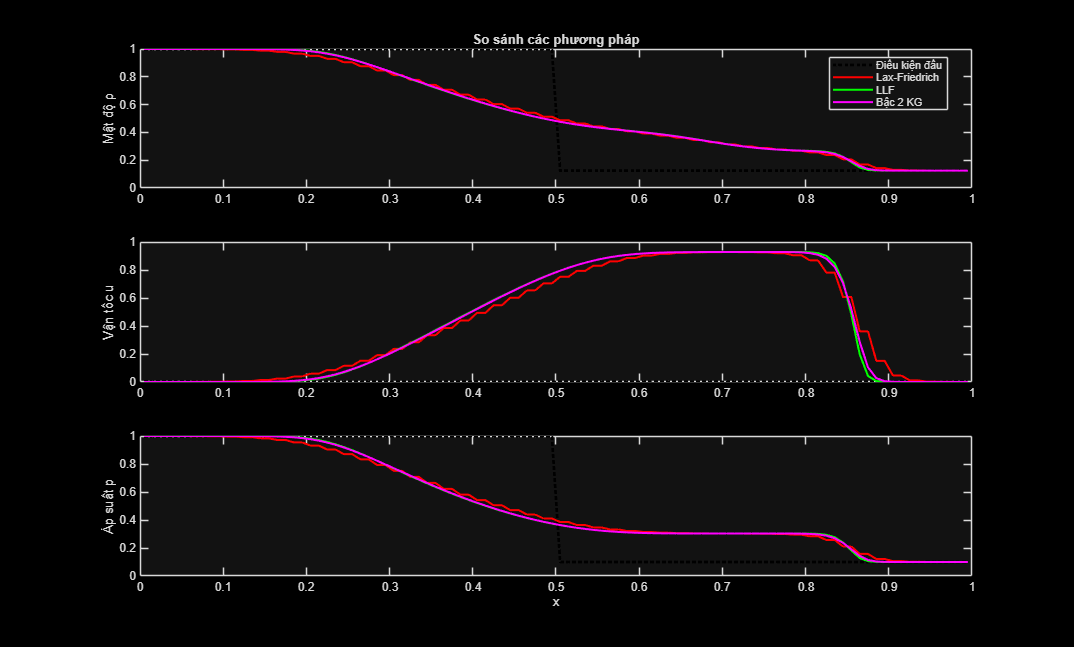

In [5]:
% So sánh các phương pháp

figure;
subplot(3,1,1);
plot(x, rho_init, 'k:', 'LineWidth', 2); hold on;
plot(x, rho_lf, 'r-', 'LineWidth', 1.5);
plot(x, rho_llf, 'g-', 'LineWidth', 1.5);
plot(x, rho_2nd, 'm-', 'LineWidth', 1.5);
title('So sánh các phương pháp'); ylabel('Mật độ ρ');
legend('Điều kiện đầu', 'Lax-Friedrich', 'LLF', 'Bậc 2 KG', 'Location', 'best');

subplot(3,1,2);
plot(x, u_init, 'k:', 'LineWidth', 2); hold on;
plot(x, u_lf, 'r-', 'LineWidth', 1.5);
plot(x, u_llf, 'g-', 'LineWidth', 1.5);
plot(x, u_2nd, 'm-', 'LineWidth', 1.5);
ylabel('Vận tốc u');

subplot(3,1,3);
plot(x, p_init, 'k:', 'LineWidth', 2); hold on;
plot(x, p_lf, 'r-', 'LineWidth', 1.5);
plot(x, p_llf, 'g-', 'LineWidth', 1.5);
plot(x, p_2nd, 'm-', 'LineWidth', 1.5);
ylabel('Áp suất p'); xlabel('x');

## 7. Phương pháp Heun - Bậc 2 Thời gian

### Lý thuyết

Phương pháp Heun là một phương pháp Runge-Kutta bậc 2 để đạt độ chính xác bậc 2 theo thời gian:

$$\frac{dW}{dt} = \mathcal{F}(W)$$

Trong đó $\mathcal{F}(W) = -\frac{1}{\Delta x}(F_{i+1/2} - F_{i-1/2})$

### Thuật toán Heun (4 bước):

1. **Tính độ dốc ban đầu**: $K_1 = \mathcal{F}(W^n)$

2. **Dự báo (Predictor)**: $W^* = W^n + \Delta t \cdot K_1$

3. **Tính độ dốc tại điểm dự báo**: $K_2 = \mathcal{F}(W^*)$

4. **Hiệu chỉnh (Corrector)**: $W^{n+1} = W^n + \frac{\Delta t}{2}(K_1 + K_2)$

### Ưu điểm:
- **Độ chính xác cao**: Bậc 2 theo thời gian
- **Ổn định tốt**: Với CFL thích hợp
- **Linh hoạt**: Có thể kết hợp với các phương pháp không gian khác nhau

### Lưu ý:
- Cần CFL nhỏ hơn để đảm bảo ổn định
- Chi phí tính toán gấp đôi so với phương pháp Euler

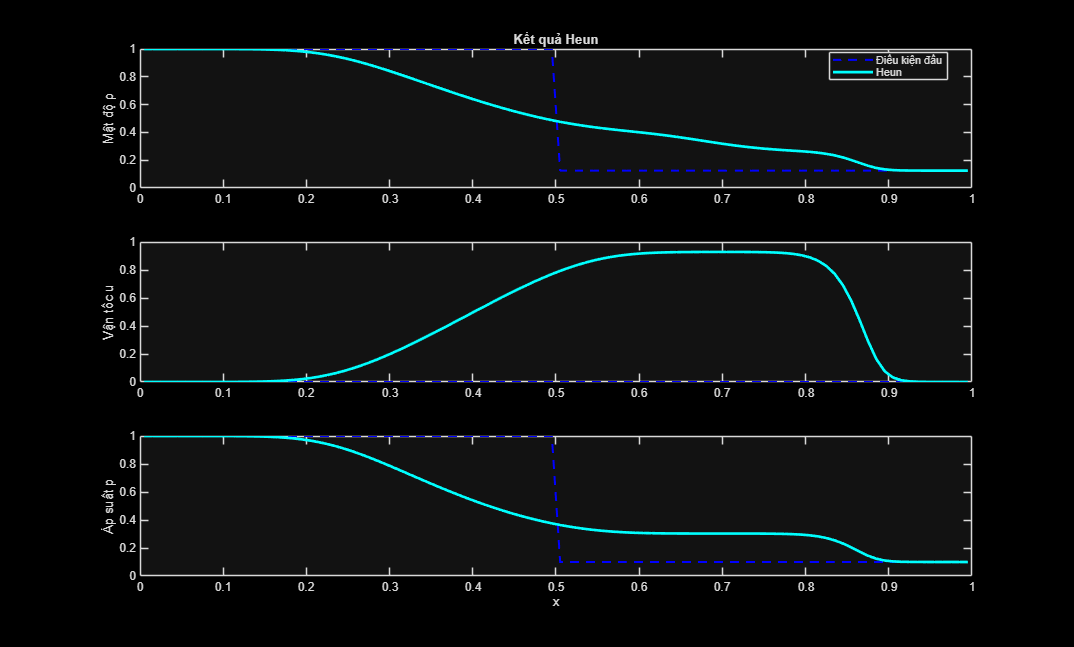

In [6]:
% Phương pháp Heun (bậc 2 thời gian)

CFL = 0.25;
c_max = 0;
for i = 1:N
    rho = W(1, i);
    u = W(2, i) / rho;
    p = (gamma - 1) * (W(3, i) - 0.5 * rho * u^2);
    c = sqrt(gamma * p / rho);
    c_max = max(c_max, abs(u) + c);
end
dt = CFL * dx / c_max;

W_heun = W;
n_steps = ceil(t_final / dt);
dt = t_final / n_steps;

for n = 1:n_steps
    K1 = zeros(3, N);
    for i = 2:N-1
        W_left = W_heun(:, i-1);
        W_center = W_heun(:, i);
        W_right = W_heun(:, i+1);
        
        u_left = W_left(2) / W_left(1);
        u_center = W_center(2) / W_center(1);
        u_right = W_right(2) / W_right(1);
        
        p_left = (gamma - 1) * (W_left(3) - 0.5 * W_left(1) * u_left^2);
        p_center = (gamma - 1) * (W_center(3) - 0.5 * W_center(1) * u_center^2);
        p_right = (gamma - 1) * (W_right(3) - 0.5 * W_right(1) * u_right^2);
        
        p_left = max(p_left, 1e-10);
        p_center = max(p_center, 1e-10);
        p_right = max(p_right, 1e-10);
        
        c_left = sqrt(gamma * p_left / W_left(1));
        c_center = sqrt(gamma * p_center / W_center(1));
        c_right = sqrt(gamma * p_right / W_right(1));
        
        alpha_left = max(abs(u_left) + c_left, abs(u_center) + c_center);
        alpha_right = max(abs(u_center) + c_center, abs(u_right) + c_right);
        
        f_left = compute_flux(W_left, gamma);
        f_center = compute_flux(W_center, gamma);
        f_right = compute_flux(W_right, gamma);
        
        F_left = 0.5 * (f_left + f_center) - 0.5 * alpha_left * (W_center - W_left);
        F_right = 0.5 * (f_center + f_right) - 0.5 * alpha_right * (W_right - W_center);
        
        K1(:, i) = -(F_right - F_left) / dx;
    end
    
    W_star = W_heun + dt * K1;
    
    K2 = zeros(3, N);
    for i = 2:N-1
        W_left = W_star(:, i-1);
        W_center = W_star(:, i);
        W_right = W_star(:, i+1);
        
        W_left(1) = max(W_left(1), 1e-10);
        W_center(1) = max(W_center(1), 1e-10);
        W_right(1) = max(W_right(1), 1e-10);
        
        u_left = W_left(2) / W_left(1);
        u_center = W_center(2) / W_center(1);
        u_right = W_right(2) / W_right(1);
        
        p_left = (gamma - 1) * (W_left(3) - 0.5 * W_left(1) * u_left^2);
        p_center = (gamma - 1) * (W_center(3) - 0.5 * W_center(1) * u_center^2);
        p_right = (gamma - 1) * (W_right(3) - 0.5 * W_right(1) * u_right^2);
        
        p_left = max(p_left, 1e-10);
        p_center = max(p_center, 1e-10);
        p_right = max(p_right, 1e-10);
        
        c_left = sqrt(gamma * p_left / W_left(1));
        c_center = sqrt(gamma * p_center / W_center(1));
        c_right = sqrt(gamma * p_right / W_right(1));
        
        alpha_left = max(abs(u_left) + c_left, abs(u_center) + c_center);
        alpha_right = max(abs(u_center) + c_center, abs(u_right) + c_right);
        
        f_left = compute_flux(W_left, gamma);
        f_center = compute_flux(W_center, gamma);
        f_right = compute_flux(W_right, gamma);
        
        F_left = 0.5 * (f_left + f_center) - 0.5 * alpha_left * (W_center - W_left);
        F_right = 0.5 * (f_center + f_right) - 0.5 * alpha_right * (W_right - W_center);
        
        K2(:, i) = -(F_right - F_left) / dx;
    end
    
    W_heun = W_heun + (dt / 2) * (K1 + K2);
end

rho_heun = W_heun(1, :);
u_heun = W_heun(2, :) ./ W_heun(1, :);
p_heun = (gamma - 1) * (W_heun(3, :) - 0.5 * W_heun(1, :) .* u_heun.^2);

figure;
subplot(3,1,1);
plot(x, rho_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, rho_heun, 'c-', 'LineWidth', 2);
title('Kết quả Heun'); ylabel('Mật độ ρ');
legend('Điều kiện đầu', 'Heun', 'Location', 'best');

subplot(3,1,2);
plot(x, u_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, u_heun, 'c-', 'LineWidth', 2);
ylabel('Vận tốc u');

subplot(3,1,3);
plot(x, p_init, 'b--', 'LineWidth', 1.5); hold on;
plot(x, p_heun, 'c-', 'LineWidth', 2);
ylabel('Áp suất p'); xlabel('x');

## 8. So sánh tổng thể các phương pháp

### Bảng so sánh:

| Phương pháp | Độ chính xác | Tính ổn định | Khuếch tán | CFL | Chi phí tính toán |
|-------------|--------------|--------------|------------|-----|-------------------|
| Lax-Friedrich | Bậc 1 | Cao | Cao | 0.4 | Thấp |
| Local LF | Bậc 1 | Cao | Trung bình | 0.4 | Thấp |
| Bậc 2 KG | Bậc 2 (KG) | Trung bình | Thấp | 0.3 | Trung bình |
| Heun | Bậc 2 (TG) | Trung bình | Thấp | 0.25 | Cao |

### Kết luận:

1. **Lax-Friedrich**: Phù hợp cho các bài toán cần ổn định cao, chấp nhận độ chính xác thấp

2. **Local Lax-Friedrich**: Cân bằng tốt giữa ổn định và độ chính xác

3. **Bậc 2 Không gian**: Tốt cho các bài toán cần độ chính xác cao theo không gian

4. **Heun**: Tốt nhất cho các bài toán cần độ chính xác cao cả không gian và thời gian

### Khuyến nghị sử dụng:
- **Bài toán đơn giản**: Local Lax-Friedrich
- **Bài toán phức tạp**: Heun kết hợp với tái cấu trúc bậc cao
- **Bài toán thời gian thực**: Lax-Friedrich

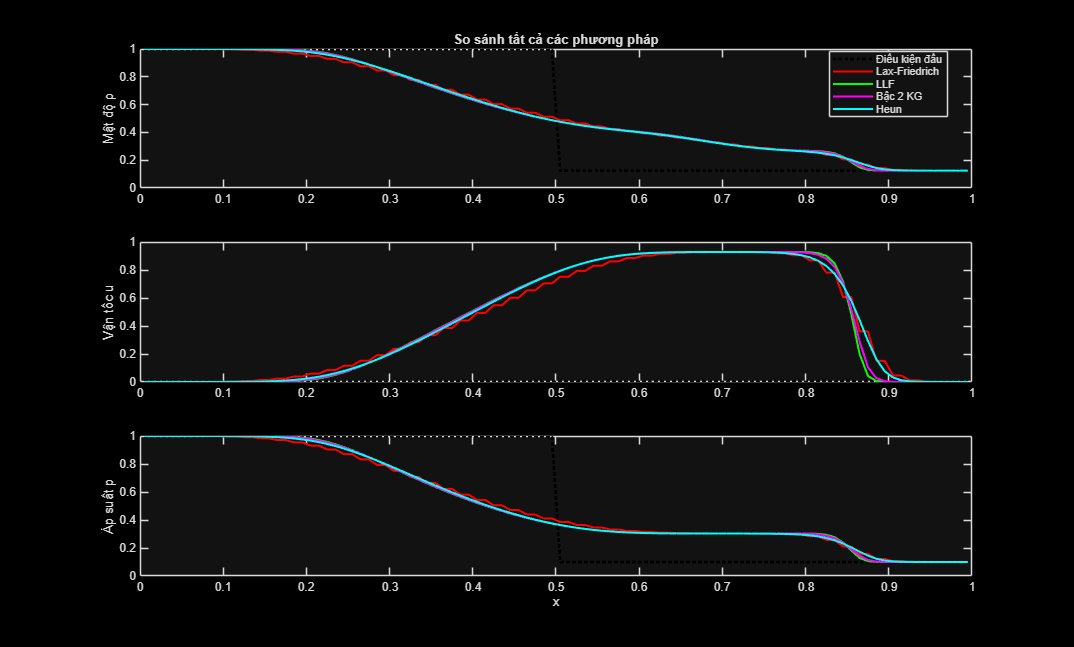

In [7]:
% So sánh tất cả các phương pháp

figure;
subplot(3,1,1);
plot(x, rho_init, 'k:', 'LineWidth', 2); hold on;
plot(x, rho_lf, 'r-', 'LineWidth', 1.5);
plot(x, rho_llf, 'g-', 'LineWidth', 1.5);
plot(x, rho_2nd, 'm-', 'LineWidth', 1.5);
plot(x, rho_heun, 'c-', 'LineWidth', 1.5);
title('So sánh tất cả các phương pháp'); ylabel('Mật độ ρ');
legend('Điều kiện đầu', 'Lax-Friedrich', 'LLF', 'Bậc 2 KG', 'Heun', 'Location', 'best');

subplot(3,1,2);
plot(x, u_init, 'k:', 'LineWidth', 2); hold on;
plot(x, u_lf, 'r-', 'LineWidth', 1.5);
plot(x, u_llf, 'g-', 'LineWidth', 1.5);
plot(x, u_2nd, 'm-', 'LineWidth', 1.5);
plot(x, u_heun, 'c-', 'LineWidth', 1.5);
ylabel('Vận tốc u');

subplot(3,1,3);
plot(x, p_init, 'k:', 'LineWidth', 2); hold on;
plot(x, p_lf, 'r-', 'LineWidth', 1.5);
plot(x, p_llf, 'g-', 'LineWidth', 1.5);
plot(x, p_2nd, 'm-', 'LineWidth', 1.5);
plot(x, p_heun, 'c-', 'LineWidth', 1.5);
ylabel('Áp suất p'); xlabel('x');